In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import root_mean_squared_error

In [2]:
FILES_FOLDER = 'Files/'
SCORES_FOLDER = 'Scores/'

MATRICES_FOLDER = f'{FILES_FOLDER}Matrices/'

FILENAMES = {
    'VA_History'       : FILES_FOLDER + 'VA_Records.csv',
    'Anime_History'    : FILES_FOLDER + 'Anime_Records.csv',
    
    'X_master'         : MATRICES_FOLDER +'X_master.pkl',
    'X_train_master'   : MATRICES_FOLDER + 'X_train_master.pkl',
    'X_test_master'    : MATRICES_FOLDER + 'X_test_master.pkl',

    'X_100roles'       : MATRICES_FOLDER+'X_100roles.pkl', 
    'X_train_100roles' : MATRICES_FOLDER + 'X_train_100roles.pkl',
    'X_test_100roles'  : MATRICES_FOLDER + 'X_test_100roles.pkl',

    'UserPrecision'             : SCORES_FOLDER + 'UserUserPrecision.csv',
    'UserSVDPrecision10'        : SCORES_FOLDER + 'UserUserSVDPrecision10.csv',
    'UserSVDPrecision150'       : SCORES_FOLDER + 'UserUserSVDPrecision150.csv',
    'UserPrecisionLessSparse'   : SCORES_FOLDER + 'UserUserPrecisionLessSparse.csv',
    'UserSVDPrecisionLessSparse': SCORES_FOLDER + 'UserUserPrecisionLessSparseSVD.csv'
}

# Data Prep
We will be joining 2 Tables.

`df_VA` contains the Project History of each VA

`USM` containts the Features of an Anime.

## Voice Actor History

We only need the following info since the rest are already present in the Anime table.

1. Anime_ID - To join at
2. Personnel_ID
3. Character_Favorites
4. Role_Main
5. Role_Support

*Note that our Voice Actor records already removed irrelevant character roles (<1 Chracter Favorites)*

In [3]:
df_VA = pd.read_csv(FILENAMES['VA_History']).drop('Unnamed: 0', axis=1)
print(df_VA.info())

df_VA = df_VA[['Anime_ID', 'Personnel_ID', 'Role_Main', 'Role_Supporting', 'Character_Favorites']] 
df_VA.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281013 entries, 0 to 281012
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Anime_ID             281013 non-null  int64  
 1   Title                281013 non-null  object 
 2   Type                 280592 non-null  object 
 3   Season               182287 non-null  object 
 4   Year                 280592 non-null  float64
 5   Character            281013 non-null  object 
 6   Character_ID         281013 non-null  int64  
 7   Character_Favorites  281013 non-null  int64  
 8   Personnel_ID         281013 non-null  int64  
 9   Personnel_Name       281013 non-null  object 
 10  Role_Main            281013 non-null  bool   
 11  Role_Supporting      281013 non-null  bool   
dtypes: bool(2), float64(1), int64(4), object(5)
memory usage: 22.0+ MB
None


,Anime_ID,Personnel_ID,Role_Main,Role_Supporting,Character_Favorites
0,3588,10002,False,True,1574
1,27,10002,True,False,974
2,20,10002,False,True,54
3,47,10002,False,True,13
4,523,10002,False,True,25


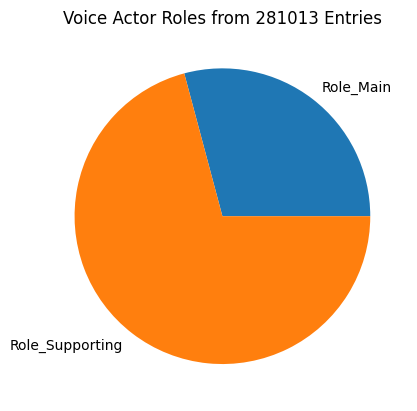

In [4]:
df_VA[['Role_Main', 'Role_Supporting']].sum().plot(kind='pie')
plt.title(f'Voice Actor Roles from {df_VA.shape[0]} Entries')
plt.show()

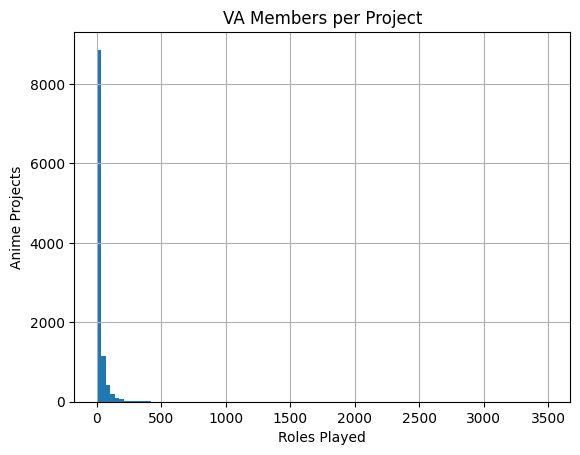

In [5]:
df_VA.Anime_ID.value_counts().hist(bins=100)
plt.title('VA Members per Project')
plt.xlabel('Roles Played')
plt.ylabel('Anime Projects')
plt.show()

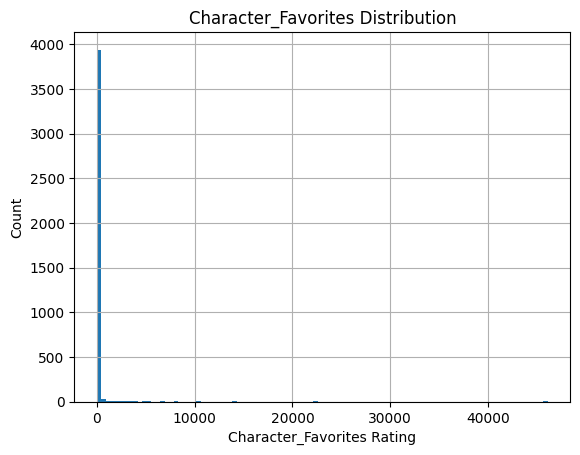

In [6]:
df_VA.Character_Favorites.value_counts().sort_values(ascending=False).hist(bins=100)
plt.title('Character_Favorites Distribution')
plt.xlabel('Character_Favorites Rating')
plt.ylabel('Count')
plt.show()

## Some Cleaning
Our data is heavily skewed to the lower ranges. We need to do some filtering to reduce noise and skew.

We will be using collaborative filtering as well so it's best to avoid sparse data.

### Remove VAs who have Played less than 5 Roles

In [7]:
ID_Filter = df_VA.Personnel_ID.value_counts()
ID_Filter = ID_Filter[ID_Filter.values >= 20]
ID_Filter

Personnel_ID
159      630
79       572
8        530
185      524
99       522
        ... 
43992     20
31349     20
30613     20
21307     20
1824      20
Name: count, Length: 3408, dtype: int64

In [8]:
df_VA = df_VA[df_VA.Personnel_ID.apply(lambda x: x in ID_Filter.index)]
df_VA.shape

(232985, 5)

### Remove Unremarkable Anime (Items) 
These are anime projects where the number of liked Chacters is neglible.

In [9]:
ID_Filter = df_VA.Anime_ID.value_counts()
ID_Filter = ID_Filter[ID_Filter.values >= 5]
ID_Filter

Anime_ID
21       2786
1735     1176
269      1110
813       801
20        796
         ... 
14045       5
25429       5
668         5
28105       5
34776       5
Name: count, Length: 7058, dtype: int64

In [10]:
df_VA = df_VA[df_VA.Anime_ID.apply(lambda x: x in ID_Filter.index)]
df_VA.shape

(225977, 5)

## Anime Features

This mostly contains encodings of

1. Genre
2. Theme
3. Source material


Non binary data are
1. Anime Score
2. Members
3. Favorites
4. Year
5. Episodes

In [11]:
USM = pd.read_csv(FILENAMES['Anime_History'])
USM = USM.loc[~USM.index.duplicated(keep='first')] # Duplicates present from shows continued airing between multiple seasons but still classified as one.
print(USM.info())

USM.head()

<class 'pandas.core.frame.DataFrame'>
Index: 15651 entries, 0 to 15650
Columns: 2202 entries, MAL_id to Episodes
dtypes: float64(2), int64(2199), object(1)
memory usage: 263.1+ MB
None


,MAL_id,Title,Is_Finished,Genre_Comedy,Genre_Romance,Genre_Supernatural,Genre_Drama,Genre_Ecchi,Genre_Action,Genre_Fantasy,...,Source_4-koma manga,Source_Light novel,Source_Manga,Source_Web manga,Score,Members,Favorites,Related_Entries,Year,Episodes
0,8769,Ore no Imouto ga Konnani Kawaii Wake ga Nai,1,1,0,0,0,0,0,0,...,0,1,0,0,6.93,702442,4515,4,2010,12.0
1,8525,Kami nomi zo Shiru Sekai,1,1,1,1,0,0,0,0,...,0,0,1,0,7.64,646117,5817,4,2010,12.0
2,7674,Bakuman.,1,1,1,0,1,0,0,0,...,0,0,1,0,8.17,638094,9531,2,2010,25.0
3,8861,Yosuga no Sora,1,0,1,0,1,1,0,0,...,0,0,0,0,6.02,523533,2627,2,2010,12.0
4,8937,Toaru Majutsu no Index II,1,0,0,0,0,0,1,1,...,0,1,0,0,7.51,473461,1731,4,2010,24.0


# Handle Missing Values

In [12]:
USM.isna().sum().sort_values(ascending=False).head()

Score                  4322
Episodes               1397
Demo_Josei                0
Rating_G - All Ages       0
Type_TV Special           0
dtype: int64

Dropping the NaN would be too costly. 

It would consume 1/4 of all entries.

## Median Imputation
Due to the presence of onesided extreme outliers, we will be using Median instead of Mean impute.

We don't actually need these values. This will be used for Content Based Filtering.

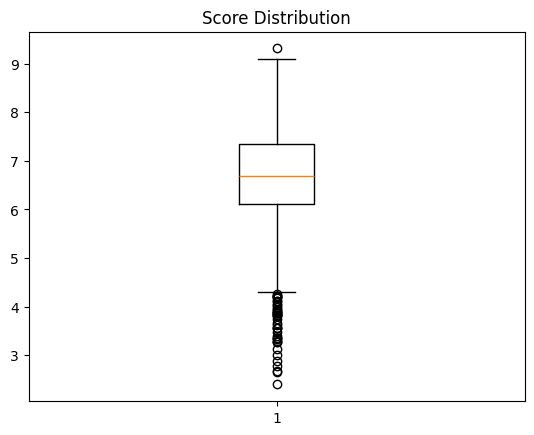

In [13]:
plt.boxplot(USM.Score.dropna())
plt.title('Score Distribution')
plt.show()

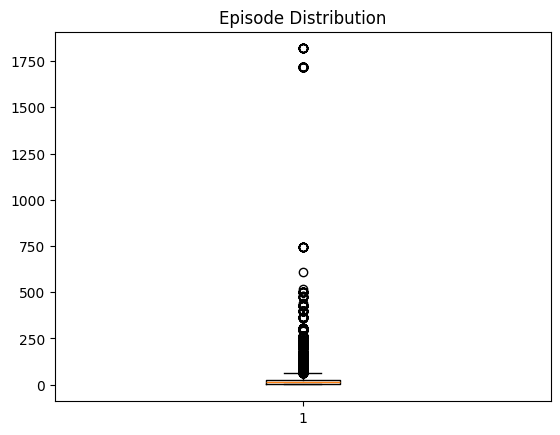

In [14]:
plt.boxplot(USM.Episodes.dropna())
plt.title('Episode Distribution')
plt.show()

In [15]:
print('Score:\t\t',USM.Score.median())
print('Episodes:\t',USM.Episodes.median())

USM.Score = USM.Score.fillna(USM.Score.median())
USM.Episodes = USM.Episodes.fillna(USM.Episodes.median())
USM.describe()

Score:		 6.69
Episodes:	 12.0


,MAL_id,Is_Finished,Genre_Comedy,Genre_Romance,Genre_Supernatural,Genre_Drama,Genre_Ecchi,Genre_Action,Genre_Fantasy,Genre_Sci-Fi,...,Source_4-koma manga,Source_Light novel,Source_Manga,Source_Web manga,Score,Members,Favorites,Related_Entries,Year,Episodes
count,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,...,15651.000000,15651.000000,15651.000000,15651.000000,15651.000000,1.565100e+04,15651.000000,15651.000000,15651.000000,15651.000000
mean,34624.439716,0.904415,0.397035,0.071369,0.068047,0.081145,0.039167,0.257428,0.254425,0.107725,...,0.025302,0.056290,0.247205,0.038592,6.715718,9.327314e+04,2243.018401,1.287010,2017.029136,29.897387
std,15704.184609,0.294031,0.489299,0.257449,0.251834,0.273066,0.193998,0.437231,0.435551,0.310042,...,0.157045,0.230489,0.431401,0.192626,0.738520,3.181769e+05,17484.566838,1.250501,4.105531,111.949305
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.400000,3.500000e+01,0.000000,0.000000,2010.000000,1.000000
25%,23219.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6.360000,5.135000e+02,0.000000,0.000000,2014.000000,1.000000
50%,36671.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6.690000,4.277000e+03,7.000000,2.000000,2017.000000,12.000000
75%,47622.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,7.100000,3.787750e+04,98.000000,2.000000,2020.000000,24.000000
max,60826.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,9.310000,4.119103e+06,234722.000000,5.000000,2024.000000,1818.000000


## Lastly Normalize the Ranges to avoid Overpowering Binaries

In [16]:
cols = ['Score', 'Members', 'Favorites', 'Related_Entries', 'Year', 'Episodes']
USM[cols] = MinMaxScaler().fit_transform(USM[cols])
USM.head()

,MAL_id,Title,Is_Finished,Genre_Comedy,Genre_Romance,Genre_Supernatural,Genre_Drama,Genre_Ecchi,Genre_Action,Genre_Fantasy,...,Source_4-koma manga,Source_Light novel,Source_Manga,Source_Web manga,Score,Members,Favorites,Related_Entries,Year,Episodes
0,8769,Ore no Imouto ga Konnani Kawaii Wake ga Nai,1,1,0,0,0,0,0,0,...,0,1,0,0,0.655572,0.170526,0.019236,0.8,0.0,0.006054
1,8525,Kami nomi zo Shiru Sekai,1,1,1,1,0,0,0,0,...,0,0,1,0,0.758321,0.156852,0.024783,0.8,0.0,0.006054
2,7674,Bakuman.,1,1,1,0,1,0,0,0,...,0,0,1,0,0.835022,0.154904,0.040605,0.4,0.0,0.013209
3,8861,Yosuga no Sora,1,0,1,0,1,1,0,0,...,0,0,0,0,0.523878,0.127091,0.011192,0.4,0.0,0.006054
4,8937,Toaru Majutsu no Index II,1,0,0,0,0,0,1,1,...,0,1,0,0,0.739508,0.114935,0.007375,0.8,0.0,0.012658


# Merge Data
Combines Anime Features with Casting Performance.

Using inner join, missing anime from a cast's work history will be discarded.

## Possible Error Thrown
Our data may be too big, because we OneHot encoded first. The extra dimensionality will affect performance.

If so, either 1. Reverse the OneHot encoding transformation or 2. Continue splicing down the VA list instead (Unspliced join requires 22GB for 1.1 million rows).

Alternatively, load the pkl files instead.

In [17]:
# df_AnimeCastings = pd.merge(USM.rename(columns={'MAL_id':'Anime_ID'}), 
#          df_VA[['Anime_ID', 'Personnel_ID', 'Character_Favorites']], 
#                on='Anime_ID', 
#                how='inner')
# df_AnimeCastings.to_pickle(FILENAMES['X_master'])


# ---------------------------------
# Skip loading since already saved.
# ---------------------------------


df_AnimeCastings = pd.read_pickle(FILENAMES['X_master'])
df_AnimeCastings

,Anime_ID,Title,Is_Finished,Genre_Comedy,Genre_Romance,Genre_Supernatural,Genre_Drama,Genre_Ecchi,Genre_Action,Genre_Fantasy,...,Source_Manga,Source_Web manga,Score,Members,Favorites,Related_Entries,Year,Episodes,Personnel_ID,Character_Favorites
0,8769,Ore no Imouto ga Konnani Kawaii Wake ga Nai,1,1,0,0,0,0,0,0,...,0,0,0.655572,0.170526,0.019236,0.8,0.0,0.006054,10981,6
1,8769,Ore no Imouto ga Konnani Kawaii Wake ga Nai,1,1,0,0,0,0,0,0,...,0,0,0.655572,0.170526,0.019236,0.8,0.0,0.006054,11622,1
2,8769,Ore no Imouto ga Konnani Kawaii Wake ga Nai,1,1,0,0,0,0,0,0,...,0,0,0.655572,0.170526,0.019236,0.8,0.0,0.006054,11641,27
3,8769,Ore no Imouto ga Konnani Kawaii Wake ga Nai,1,1,0,0,0,0,0,0,...,0,0,0.655572,0.170526,0.019236,0.8,0.0,0.006054,1472,38
4,8769,Ore no Imouto ga Konnani Kawaii Wake ga Nai,1,1,0,0,0,0,0,0,...,0,0,0.655572,0.170526,0.019236,0.8,0.0,0.006054,14753,507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528348,58606,Girls & Panzer: Saishuushou Part 4 Specials,1,1,0,0,0,0,0,0,...,0,0,0.707670,0.000709,0.000009,0.0,1.0,0.000550,27761,1
528349,58606,Girls & Panzer: Saishuushou Part 4 Specials,1,1,0,0,0,0,0,0,...,0,0,0.707670,0.000709,0.000009,0.0,1.0,0.000550,40,212
528350,58606,Girls & Panzer: Saishuushou Part 4 Specials,1,1,0,0,0,0,0,0,...,0,0,0.707670,0.000709,0.000009,0.0,1.0,0.000550,413,344
528351,58606,Girls & Panzer: Saishuushou Part 4 Specials,1,1,0,0,0,0,0,0,...,0,0,0.707670,0.000709,0.000009,0.0,1.0,0.000550,8555,465


### Free Memory
We desperately need it.

In [18]:
del USM
del df_VA

## Split Data
Note: For this iteration, the goal of splitting data isn't actually to conduct 2 separate tests like in  ML Training. 

But rather it's to mask the known ratings/starred in already.

In [19]:
# X_train, X_test = train_test_split(df_AnimeCastings.drop(columns=['Title']), random_state=42, test_size=0.2)
# X_train.to_pickle(FILENAMES['X_train_master'])
# X_test.to_pickle(FILENAMES['X_test_master'])


# ---------------------------------
# Skip loading since already saved.
# ---------------------------------



X_train = pd.read_pickle(FILENAMES['X_train_master'])
X_test = pd.read_pickle(FILENAMES['X_test_master'])

print('Train:\t', X_train.shape[0])
print('Test:\t', X_test.shape[0])

Train:	 422682
Test:	 105671


These are the True Positives.

Any other recommendations are mistaken.

In [20]:
Y_test = X_test[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(list)
Y_test

,Anime_ID
Personnel_ID,
1,"[21, 50528, 38234, 28257, 8687, 21, 8687, 3980..."
2,"[28977, 9969, 31581, 9712, 50250, 34566, 28977..."
3,"[15651, 19291, 235, 235, 21, 1565, 21, 1735, 2..."
4,"[8456, 21, 30925, 49785, 12963, 21, 10359, 306..."
5,"[9136, 28497, 38235, 1735, 1735, 22043, 40389,..."
...,...
59534,"[24405, 48583, 6702, 6702, 6702, 24405, 42892,..."
59535,"[36896, 6702, 53802, 6702, 28771, 11021, 52305..."
59626,"[7817, 11633, 9062, 10080, 11111]"


In [21]:
X_train = X_train[['Character_Favorites', 'Anime_ID', 'Personnel_ID']]

### Free Memory
We already have the split and truth.

In [22]:
del df_AnimeCastings
del X_test

# Modeling

Now we generate a matrix. 

Users are the Voice Actors, while Items are the Anime Projects.

The value shared is their average Character rankings (if they played multiple characters). 

In [23]:
df_PerformanceScoring = pd.pivot_table(X_train, index='Personnel_ID', columns='Anime_ID', values='Character_Favorites', aggfunc='mean')
df_PerformanceScoring.head()

Anime_ID,21,235,269,516,777,918,966,1199,1565,1604,...,59770,59790,59820,59989,60012,60022,60063,60076,60108,60480
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,238.0,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,142.0,NaN,NaN,NaN,NaN,NaN
2,6788.0,NaN,119.333333,NaN,NaN,12.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,90.0,3.0,6407.000000,3.0,NaN,234.0,NaN,NaN,497.272727,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,8021.0,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,6189.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Standardize the ratings based on Actor's received ratings.

Big leagues will receive higher Favorites while the lesser known receive less.

So balance it out.

In [24]:
df_PerformanceScoring = df_PerformanceScoring.sub(df_PerformanceScoring.mean(1), axis=0).div(df_PerformanceScoring.std(1), axis=0)

In [25]:
def CalcSparsity(df):
    print('Sparsity: ', np.round(100 * df.notnull().sum().sum() / (df.shape[0] * df.shape[1]), 2), '%')

In [26]:
CalcSparsity(df_PerformanceScoring)

Sparsity:  0.83 %


### Acceptable Sparsity
The recommneded threshold is 0.5%, but it can be increased by dropping sparse items/users.

To keep things balanced, both Users and Items must have at least 10 entries each.

In [27]:
CalcSparsity(df_PerformanceScoring.dropna(thresh=10, axis=0).dropna(thresh=10, axis=1))
CalcSparsity(df_PerformanceScoring.dropna(thresh=20, axis=0))
CalcSparsity(df_PerformanceScoring.dropna(thresh=20, axis=1))

df_PerformanceScoring = df_PerformanceScoring.dropna(thresh=10, axis=0).dropna(thresh=10, axis=1)

Sparsity:  1.37 %
Sparsity:  1.28 %
Sparsity:  1.67 %


## Impute
Lastly, we'll fill the missing values with 0 mean.

Thanks to StandardScaler adjusting the values' variance ranges.

In [28]:
df_PerformanceScoring = df_PerformanceScoring.fillna(0)
df_PerformanceScoring

Anime_ID,21,235,269,516,777,918,966,1199,1565,1604,...,59465,59493,59497,59571,59820,59989,60012,60022,60063,60108
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,-0.395056,0.000000,-0.447522,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.416308,0.0,0.00000,0.0
2,0.101151,0.000000,-0.283943,0.000000,0.0,-0.290113,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0
3,-0.430228,-0.494858,4.262502,-0.494858,0.0,-0.323254,0.0,0.0,-0.127676,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0
4,-0.437319,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.94146,0.0
5,0.000000,0.000000,0.000000,0.000000,0.0,2.357809,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59534,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0
59535,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0
59626,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0


# Item-item Filtering

We'll verify first on Anime items.

Similarity in this context means, Anime who have similar cast ratings (Character Favorites).

The reccomendations generated by this would essentially recommend a Project because of similar Casting scores.

In [29]:
df_CastingSimilarity = pd.DataFrame(cosine_similarity(df_PerformanceScoring.T), index=df_PerformanceScoring.columns, columns=df_PerformanceScoring.columns)
df_CastingSimilarity = df_CastingSimilarity.groupby('Anime_ID').sum()
df_CastingSimilarity.head(10)

Anime_ID,21,235,269,516,777,918,966,1199,1565,1604,...,59465,59493,59497,59571,59820,59989,60012,60022,60063,60108
Anime_ID,,,,,,,,,,,,,,,,,,,,,
21,1.000000,-0.053567,-0.032223,-0.088825,-0.001500,0.006348,-0.026922,0.024054,-0.039896,0.007343,...,-0.007098,-0.007921,0.016856,-0.017498,-0.00787,-0.007346,-0.001650,0.011699,-0.006800,0.006128
235,-0.053567,1.000000,-0.034741,0.041926,-0.018608,-0.006432,0.042616,0.023121,0.053449,-0.011114,...,0.001549,0.005483,-0.033326,-0.042854,0.00000,0.004536,0.008084,-0.046429,-0.003017,-0.039536
269,-0.032223,-0.034741,1.000000,-0.047066,-0.008689,-0.039418,-0.004149,-0.020858,-0.010133,-0.011368,...,0.085807,-0.004479,0.011288,-0.010432,0.00000,-0.003245,0.001975,-0.005430,-0.001573,-0.005670
516,-0.088825,0.041926,-0.047066,1.000000,-0.050820,0.021719,0.095270,0.044860,0.079803,0.017772,...,0.007931,0.002489,0.004262,-0.026435,0.00000,0.002417,0.003013,-0.125491,0.000000,-0.092909
777,-0.001500,-0.018608,-0.008689,-0.050820,1.000000,-0.027359,0.000658,-0.009445,-0.027027,-0.007845,...,-0.029029,0.000379,0.000000,-0.004619,0.00000,0.000000,0.000000,-0.009387,-0.000861,0.000000
918,0.006348,-0.006432,-0.039418,0.021719,-0.027359,1.000000,0.011922,-0.001194,-0.019188,-0.007939,...,-0.001131,0.001306,0.000000,-0.008122,0.00000,0.002823,-0.003763,-0.019109,0.000000,-0.019779
966,-0.026922,0.042616,-0.004149,0.095270,0.000658,0.011922,1.000000,0.029214,0.068158,-0.010781,...,-0.008914,0.001830,0.000000,-0.028575,0.00000,0.000000,0.000000,-0.026137,0.000000,-0.034681
1199,0.024054,0.023121,-0.020858,0.044860,-0.009445,-0.001194,0.029214,1.000000,0.026829,-0.003426,...,0.006066,0.000000,0.000000,-0.006120,0.00000,0.000000,0.004919,0.000000,-0.006535,-0.058262
1565,-0.039896,0.053449,-0.010133,0.079803,-0.027027,-0.019188,0.068158,0.026829,1.000000,0.008395,...,0.007875,0.003545,-0.058273,-0.009842,0.00000,0.005259,0.003939,-0.099537,-0.021383,-0.082379


### Verify

What to expect?


Try a long running series. They should would share consistent characters, VA cast and thereby personnel ratings.

In [30]:
ANIME_LIST = pd.read_csv(FILENAMES['VA_History'])[['Anime_ID', 'Title', 'Personnel_ID']].drop_duplicates().groupby(['Anime_ID', 'Title']).agg(list).reset_index().set_index('Anime_ID')

In [31]:
def GetAnimeWithSimilarCastingPerformance(ANIME_ID : np.int64, SIMILARITY_THRESHOLD : float):
    try:
        similar_anime = df_CastingSimilarity.loc[ANIME_ID].sort_values(ascending=False)
        similar_anime = similar_anime[similar_anime.values > SIMILARITY_THRESHOLD]
        
        
        df = pd.concat([ANIME_LIST.loc[similar_anime.index].reset_index(), 
                   pd.Series(similar_anime.values)], 
                  axis=1, 
                  ignore_index=True)
        df.columns = ['Anime_ID', 'Anime_Title', 'Personnel_ID', 'Similarity']
        return df

    
    except Exception as e:
        print('ERROR: ID may not be in training set', e)

#### Mainstream Series

In [32]:
GetAnimeWithSimilarCastingPerformance(16498, SIMILARITY_THRESHOLD = 0.3)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,16498,Shingeki no Kyojin,"[10028, 1003, 10065, 10185, 1030, 1047, 1048, ...",1.000000
1,23775,Shingeki no Kyojin Movie 1: Guren no Yumiya,"[10028, 10065, 1047, 1048, 1052, 1057, 10701, ...",0.743169
2,35760,Shingeki no Kyojin Season 3,"[10024, 10028, 10065, 10073, 10185, 1030, 1047...",0.704022
3,36702,Shingeki no Kyojin Season 2 Movie: Kakusei no ...,"[10028, 10065, 1047, 1048, 1057, 10696, 10912,...",0.693725
4,25777,Shingeki no Kyojin Season 2,"[10028, 10065, 1047, 1048, 1057, 10696, 10912,...",0.692239
5,23777,Shingeki no Kyojin Movie 2: Jiyuu no Tsubasa,"[10185, 1047, 1048, 1057, 10668, 10815, 10912,...",0.673698
6,18397,Shingeki no Kyojin OVA,"[10065, 1047, 1048, 11030, 11236, 118, 12400, ...",0.662457
7,38524,Shingeki no Kyojin Season 3 Part 2,"[10021, 10024, 10028, 10065, 10183, 10185, 103...",0.651011
8,48583,Shingeki no Kyojin: The Final Season Part 2,"[1030, 1047, 1048, 1057, 10710, 10881, 11236, ...",0.569008
9,40028,Shingeki no Kyojin: The Final Season,"[10024, 10028, 10065, 10185, 1030, 1047, 1048,...",0.531500


#### Niche Series

In [33]:
GetAnimeWithSimilarCastingPerformance(34798, SIMILARITY_THRESHOLD = 0.3)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,34798,Yuru Camp△,"[10881, 11184, 12013, 13, 14477, 146, 1472, 15...",1.000000
1,58855,Yuru Camp△ Season 3 Specials,"[11184, 12013, 146, 18057, 21543, 31597, 34785...",0.857211
2,38474,Yuru Camp△ Season 2,"[10881, 11184, 11661, 12013, 13, 14477, 146, 1...",0.837121
3,53410,Yuru Camp△ Season 3,"[10881, 11184, 11661, 12013, 146, 156, 158, 18...",0.544961
4,51498,Masamune-kun no Revenge R,"[1047, 10795, 10981, 1108, 11297, 11359, 15903...",0.531427
5,8857,Nichijou: Nichijou no 0-wa,"[12144, 159, 18057, 25719, 261, 56, 581, 6729,...",0.402970
6,10165,Nichijou,"[10073, 10292, 103, 10668, 113, 1149, 1151, 11...",0.332259


In [34]:
GetAnimeWithSimilarCastingPerformance(31418, SIMILARITY_THRESHOLD = 0.2)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,31418,KanColle Movie,"[10981, 1105, 11184, 11622, 12452, 13, 14441, ...",1.000000
1,30455,KanColle: Itsuka Ano Umi de,"[10765, 10981, 11184, 12285, 12452, 12941, 13,...",0.648944
2,21511,Kantai Collection: KanColle,"[10701, 10881, 10943, 11184, 11622, 1210, 1245...",0.333429
3,49894,Eiyuu Kyoushitsu,"[11184, 17629, 177, 184, 19371, 28755, 40903, ...",0.310473
4,28883,Hidan no Aria AA,"[10217, 10765, 10943, 11622, 132, 18057, 189, ...",0.289404
5,32171,Ange Vierge,"[11622, 12016, 12490, 185, 18759, 19371, 19605...",0.289311
6,16051,Ro-Kyu-Bu! SS,"[10981, 11641, 16135, 177, 185, 5250, 655, 663...",0.268971
7,10196,Baby Princess 3D Paradise 0 [Love],"[105, 11359, 1592, 185, 504, 53, 655, 6686, 67...",0.221584
8,34607,Lostorage Conflated WIXOSS,"[10765, 11622, 11641, 11787, 12014, 12652, 13,...",0.219927
9,15609,"Kono Naka ni Hitori, Imouto ga Iru!: Ani, Imou...","[10073, 10217, 10981, 11622, 11789, 145, 159, ...",0.217300


## Test For Yourself
Random choice. Refresh as many times as needed.



In [35]:
GetAnimeWithSimilarCastingPerformance(df_CastingSimilarity.sample().index[0], SIMILARITY_THRESHOLD = -0.9)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,54265,Kekkon Yubiwa Monogatari,"[10071, 12400, 184, 18511, 21357, 22625, 255, ...",1.000000
1,55597,Hananoi-kun to Koi no Yamai,"[10071, 15743, 1762, 185, 22179, 46131, 46294,...",0.169544
2,50923,Mushikaburi-hime,"[10071, 10989, 1489, 1762, 176, 21411, 26063, ...",0.167705
3,42395,Shakunetsu Kabaddi,"[15919, 16635, 17635, 18227, 270, 27773, 33995...",0.164158
4,40908,Kemono Jihen,"[10024, 11453, 1163, 1423, 15919, 16635, 16673...",0.144347
...,...,...,...,...
2816,11255,Ikkitousen: Shuugaku Toushi Keppuuroku,"[1048, 10701, 10711, 117, 119, 1212, 1325, 132...",-0.166363
2817,8507,Ikkitousen: Xtreme Xecutor Specials,"[100, 10696, 10701, 10711, 117, 119, 1212, 132...",-0.187478
2818,38425,Ikkitousen: Western Wolves,"[1048, 117, 119, 1212, 1325, 18369, 184, 245, ...",-0.189285
2819,49342,Shin Ikkitousen,"[1048, 117, 119, 1325, 184, 327, 380, 38451, 4...",-0.189780


## Discussion
It works well and reccomends Anime projects that often share a similar cast throughout long series.

Positives are where the casting performed best, while negatives are possibly the same cast at their worst.

More surpising is that it seems to be able to observe certain rules. 

The most similar recommendations often lie within the same series or field. 

Be it theme, media type, or maybe even genre. Most possibly because the Actor specializes in said field but their performance may vary as good or bad according to fan ratings.

This indeed proves why Matrix Factorization can discover Latent Features.

### Notice a problem?
Some reccommendations are numeorous while others are very few when filtering with the threshold.

An alternative may be used which is Top K recommendations. 

Regardless of similarity value, recommend the Top of the list.

### Use Case
Item-item filtering in this scenario matches the Performance of the VA Team with the Anime.

Provide it your work history, and it could recommend similar Anime Projects as potential work because of the presence of your previous workmates.

It also tells you, the Team's worst performances in the negatives.

### Continue
However this is merely a verification since Titles are more esily discernable.

Seeing that it works, we can proceed to User-User matrices.

# User-User Filtering

We'll return to the original matrix to produce a similarity matrix for users.

Similarity in this context means, Actors who have been in the same project with similar ratings (Character Favorites). 

In [36]:
df_Collabs = pd.DataFrame(cosine_similarity(df_PerformanceScoring), index=df_PerformanceScoring.index, columns=df_PerformanceScoring.index)
df_Collabs.head(10)

Personnel_ID,1,2,3,4,5,6,8,9,10,11,...,59418,59420,59464,59466,59476,59534,59535,59626,59793,59823
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.002899,-0.011102,-0.004424,-0.002362,0.005250,0.000090,0.004687,-0.004377,-0.025174,...,0.000177,0.000000,0.000000,0.008308,-0.003321,0.006200,0.002227,0.009873,0.005599,0.008156
2,-0.002899,1.000000,-0.094417,-0.042828,0.345692,-0.008148,0.553214,0.003366,-0.003500,-0.019986,...,-0.012901,0.003419,-0.021337,0.004680,0.003286,0.010259,0.006381,0.000000,-0.001668,0.004472
3,-0.011102,-0.094417,1.000000,0.013762,-0.106356,-0.013743,-0.090351,-0.014897,0.108371,-0.025042,...,0.366125,-0.039722,0.000000,-0.054648,0.000000,0.000000,0.006753,0.000000,-0.009539,-0.110281
4,-0.004424,-0.042828,0.013762,1.000000,-0.032599,-0.010801,0.040162,0.002848,-0.009914,-0.066538,...,0.008133,0.000000,0.000000,0.005131,0.009263,-0.009346,-0.004628,0.000000,-0.000476,0.002104
5,-0.002362,0.345692,-0.106356,-0.032599,1.000000,0.122997,0.287012,-0.014423,-0.004577,0.009759,...,-0.026554,-0.011404,0.000000,0.000000,0.009042,0.005204,0.001379,0.000000,0.103800,0.358223
6,0.005250,-0.008148,-0.013743,-0.010801,0.122997,1.000000,-0.003709,-0.009652,-0.012764,-0.009130,...,-0.018500,-0.001301,-0.001655,0.003758,0.192661,-0.009047,0.000000,0.000000,0.075883,0.143943
8,0.000090,0.553214,-0.090351,0.040162,0.287012,-0.003709,1.000000,0.002209,-0.003416,-0.031835,...,-0.013918,0.001794,0.004870,0.005609,0.004048,-0.003049,-0.002819,0.000000,-0.004687,0.025289
9,0.004687,0.003366,-0.014897,0.002848,-0.014423,-0.009652,0.002209,1.000000,-0.020414,0.037648,...,0.008154,0.005656,0.003304,-0.019680,0.007203,0.000000,0.000000,0.006681,-0.014142,-0.043529
10,-0.004377,-0.003500,0.108371,-0.009914,-0.004577,-0.012764,-0.003416,-0.020414,1.000000,-0.020636,...,0.167141,0.000000,0.000000,-0.027407,0.003161,-0.000419,-0.021621,0.006914,-0.023275,-0.026807


In [37]:
PERSONNEL_LIST = pd.read_csv(FILENAMES['VA_History'])[['Personnel_ID', 'Personnel_Name', 'Title', 'Character', 'Anime_ID']].groupby(['Personnel_ID', 'Personnel_Name']).agg(list)

In [38]:
def GetMostSimilarUsersAndProject(PERSONNEL_ID : np.uint, K : np.uint = 10 ):
    ALREADY_CASTED = df_PerformanceScoring.loc[PERSONNEL_ID] != 0
    
    
    df = pd.DataFrame()
    df[['Similar_Personnel', 'Personnel_Similarity']] = df_Collabs.loc[PERSONNEL_ID].sort_values(ascending=False)[1:K+1].reset_index()
    
    df['Shared_Projects'] = [
        sum(1 for a, b in zip(df_PerformanceScoring.loc[PERSONNEL_ID], df_PerformanceScoring.loc[ID]) if a != 0 and b != 0)
        for ID in df.Similar_Personnel
    ]

    df[['Recommended_Similar_Actors_Project', 'Project_Character_Favorites']] = df_PerformanceScoring.loc[df.Similar_Personnel, ~ALREADY_CASTED].mean().sort_values(ascending=False).head(K).reset_index()
    df['Is_Casted(Y)'] = [1 if x in Y_test.loc[PERSONNEL_ID].Anime_ID else 0 for x in df.Recommended_Similar_Actors_Project]
    
    
    print({
        'Total' : df.shape[0],
        'True_Positive': len(set(df.Recommended_Similar_Actors_Project) & set(Y_test.loc[PERSONNEL_ID].Anime_ID))
    })

    return df

In [39]:
def GetPersonnelFromColabs(PERSONNEL_ID : np.int64, SIMILARITY_THRESHOLD : float):
    try:
        similar_personnel = df_Collabs.loc[PERSONNEL_ID].sort_values(ascending=False)
        similar_personnel = similar_personnel[similar_personnel.values > SIMILARITY_THRESHOLD]
        
        
        df = pd.concat([PERSONNEL_LIST.loc[similar_personnel.index].reset_index(), 
                   pd.Series(similar_personnel.values)], 
                  axis=1, 
                  ignore_index=True)
        df.columns = ['Personnel_ID', 'Personnel_Name', 'Projects', 'Character', 'Anime_ID', 'Similarity']
        return df

    except Exception as e:
        print('ERROR: ID may not be in training set', e)

In [40]:
GetMostSimilarUsersAndProject(PERSONNEL_ID = 21, K = 10)

{'Total': 10, 'True_Positive': 1}


,Similar_Personnel,Personnel_Similarity,Shared_Projects,Recommended_Similar_Actors_Project,Project_Character_Favorites,Is_Casted(Y)
0,16,0.738175,9,28755,1.597642,0
1,81,0.720663,11,8246,0.323141,0
2,178,0.718450,7,10589,0.154611,1
3,410,0.690820,6,35330,0.129099,0
4,8517,0.656717,7,31580,0.066307,0
5,23751,0.647921,7,25939,0.045493,0
6,8515,0.617616,10,33050,0.040615,0
7,23755,0.617396,9,31706,0.040615,0
8,337,0.611658,8,25537,0.040615,0
9,761,0.607836,10,7559,0.040615,0


In [41]:
GetPersonnelFromColabs(PERSONNEL_ID = 21, SIMILARITY_THRESHOLD = 0.8)

,Personnel_ID,Personnel_Name,Projects,Character,Anime_ID,Similarity
0,21,Inoue Kazuhiko,"[Natsume Yuujinchou Shichi Special, Akuyaku Re...","[Madara, Tondabayashi, Kenzaburou, Madara, Jen...","[60302, 57719, 55823, 58714, 59131, 58488, 497...",1.0


In [42]:
GetPersonnelFromColabs(PERSONNEL_ID = 160, SIMILARITY_THRESHOLD = 0.3)

,Personnel_ID,Personnel_Name,Projects,Character,Anime_ID,Similarity
0,160,Koyasu Takehito,"[3-nen Z-gumi Ginpachi-sensei, Jujutsu Kaisen:...","[Takasugi, Shinsuke, Fushiguro, Touji, Shindou...","[54757, 59654, 49363, 58473, 59571, 57559, 587...",1.000000
1,43800,Júnior Francisco,"[Sakamoto Days, Bleach: Sennen Kessen-hen - So...","[Boiled, Jaegerjaquez, Grimmjow, Tarou, Welkin...","[58939, 56784, 57334, 54857, 56704, 55701, 494...",0.708373
2,9868,Souterelle Frédéri,"[Bleach: Sennen Kessen-hen - Soukoku-tan, Blea...","[Zaraki, Kenpachi, Aizen, Sousuke, Kyouraku, S...","[56784, 56784, 56784, 56784, 56784, 56196, 585...",0.642796
3,340,Seitz Patrick,"[Ishura 2nd Season, Ore dake Level Up na Ken S...","[Narrator, Kim, Chul, Zaraki, Kenpachi, Kurosa...","[58484, 58567, 56784, 56784, 56784, 56196, 497...",0.634990
4,57209,Winslow Mar,"[Seirei Gensouki 2, Dandadan, Murai no Koi, Ki...","[Sendou, Takahisa, Enjouji, Jin, Kiriyama, Aki...","[50306, 57334, 52080, 55701, 55855, 55911, 575...",0.629935
5,352,Epcar Richard,"[Bleach: Sennen Kessen-hen - Soukoku-tan, Plut...","[Yhwach, Heracles, Yhwach, Jigen, Daisuke, Zan...","[56784, 35737, 53998, 53109, 41467, 41467, 417...",0.592347
6,37669,Ramos Mauro,"[Beastars Final Season, Nige Jouzu no Wakagimi...","[Gouhin , Ogasawara, Sadamune, Tarantino, Jaco...","[49469, 54724, 51122, 40357, 49387, 45649, 500...",0.577083
7,52883,Mazzei Wilken,[Ore dake Level Up na Ken Season 2: Arise from...,"[Hwang, Dong-Soo, Kibito, Phonsekal, Laure, Na...","[58567, 56894, 59989, 58510, 55701, 54789, 522...",0.572125
8,11659,Takamori Natsumi,"[Summer Pockets, Kimi to Idol Precure♪, Hoshik...","[Sorakado, Ao, Shigure, Kokoro, Emihara-sensei...","[50694, 60407, 53262, 39167, 39167, 54650, 549...",0.565619
9,1534,Longo Thiago,"[Hanma Baki vs. Kengan Ashura, Maou Gakuin no ...","[Orochi, Katsumi, Revalschned, Datz, Sean, Oro...","[58510, 48418, 52741, 51318, 45649, 49163, 501...",0.563313


In [43]:
GetMostSimilarUsersAndProject(PERSONNEL_ID = 160, K = 10)

{'Total': 10, 'True_Positive': 1}


,Similar_Personnel,Personnel_Similarity,Shared_Projects,Recommended_Similar_Actors_Project,Project_Character_Favorites,Is_Casted(Y)
0,43800,0.708373,14,31933,0.783114,0
1,9868,0.642796,19,53998,0.426392,0
2,340,0.634990,28,34572,0.408684,0
3,57209,0.629935,12,48661,0.369718,1
4,352,0.592347,8,56784,0.225727,0
5,37669,0.577083,7,37991,0.224042,0
6,52883,0.572125,11,32051,0.197988,0
7,11659,0.565619,5,53890,0.197988,0
8,1534,0.563313,7,33338,0.197988,0
9,46054,0.549767,6,40748,0.183683,0


## Why such low scores?

Note that our K is set to generate Top 10 predictions, but look at our Truths.

Many have less than K correct answers.

In short our testing is meaningless because the correct answers are too little.

In [44]:
Y_test.Anime_ID.apply(len).min()

np.int64(1)

We'll remedy this by returning to our dataset and being stricter.

### Regenerate the Records but Filter to Actors reqquiring threshold projects taken
Only consider the Actors with more than 100 noteworthy projects completed.

### Preprocessing Oversights
The mistake made was failing to count only the unique. 

This would affect our filtering if not catched.

```python
# Still over 800k entries
total_ProjectsTaken = df_AnimeCastings[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(list)

# 100k+ entries
total_ProjectsTaken = df_AnimeCastings[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(set)
```

#### Train Test Split
Additionally, stratify the split so it's proportional between Train and Test.

In [45]:
# scaler = StandardScaler()
# df_AnimeCastings = pd.read_pickle(FILENAMES['X_master'])

# total_ProjectsTaken = df_AnimeCastings[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(set)
# total_ProjectsTaken = total_ProjectsTaken[total_ProjectsTaken.Anime_ID.apply(lambda x : len(x) > 100)]
# df_AnimeCastings = df_AnimeCastings[df_AnimeCastings.Personnel_ID.apply(lambda x : x in total_ProjectsTaken.index)]
# df_AnimeCastings['STD_Character_Favorites'] = df_AnimeCastings[['Personnel_ID', 'Character_Favorites']].groupby('Personnel_ID')['Character_Favorites'].transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())

# df_AnimeCastings.to_pickle(FILENAMES['X_100roles'])

# X_train, X_test = train_test_split(df_AnimeCastings, random_state=42, test_size=0.5, stratify=df_AnimeCastings['Personnel_ID'])

# del df_AnimeCastings

# X_train.to_pickle(FILENAMES['X_train_100roles'])
# X_test.to_pickle(FILENAMES['X_test_100roles'])


# ---------------------------------
# Skip loading since already saved.
# ---------------------------------


X_train = pd.read_pickle(FILENAMES['X_train_100roles'])
X_test  = pd.read_pickle(FILENAMES['X_test_100roles'])

In [46]:
X_train = X_train[['Anime_ID', 'Personnel_ID', 'Character_Favorites', 'STD_Character_Favorites']]
X_test = X_test[['Anime_ID', 'Personnel_ID', 'Character_Favorites', 'STD_Character_Favorites']]

Extract the Y truths.

In [47]:
Y_train = X_train[['Personnel_ID', 'Anime_ID', 'Character_Favorites', 'STD_Character_Favorites']].groupby(['Personnel_ID', 'Anime_ID']).mean()
Y_train

Y_test = X_test[['Personnel_ID', 'Anime_ID', 'Character_Favorites', 'STD_Character_Favorites']].groupby(['Personnel_ID', 'Anime_ID']).mean()
Y_test

Character_Favorites  STD_Character_Favorites
Personnel_ID Anime_ID                                              
1            21                      238.0                -0.259482
             269                       1.0                -0.325588
             5690                    816.0                -0.098260
             6547                      2.0                -0.325310
             6702                      5.0                -0.324473
...                                    ...                      ...
56593        54141                     2.0                -0.241122
             54492                  1557.0                 0.202248
             54724                     7.0                -0.239697
             55597                     1.0                -0.241407
             58449                     5.0                -0.240267

[28224 rows x 2 columns]

### Top K = 20
The smallest number of projects an Actor in Test case has taken is...

But we can still use a lower K.

In [48]:
X_test[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(set).Anime_ID.apply(len).min()

np.int64(55)

In [49]:
del X_test

In [50]:
df_PerformanceScoring = pd.pivot_table(X_train, index='Personnel_ID', columns='Anime_ID', values='STD_Character_Favorites', aggfunc='mean')
del X_train

CalcSparsity(df_PerformanceScoring)
df_PerformanceScoring = df_PerformanceScoring.fillna(0)

df_Collabs = pd.DataFrame(cosine_similarity(df_PerformanceScoring), index=df_PerformanceScoring.index, columns=df_PerformanceScoring.index)
df_Collabs.head(10)

Sparsity:  2.47 %


Personnel_ID,1,2,3,5,6,8,10,11,13,14,...,42840,44343,44721,45362,47003,47671,47713,51029,56579,56593
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.000166,0.038540,0.009840,0.003270,-0.002108,-0.007237,-0.010437,0.229569,-0.012392,...,-0.000031,0.002101,-0.000155,0.000000,0.000909,0.000384,0.000608,0.001521,-0.001944,-0.000309
2,-0.000166,1.000000,-0.063232,0.079874,-0.020352,0.434532,-0.002445,-0.067928,-0.002062,-0.000123,...,-0.008303,-0.019596,0.002178,0.003102,-0.022523,0.001888,0.000364,-0.002904,-0.016592,0.000938
3,0.038540,-0.063232,1.000000,-0.001711,-0.017563,-0.039581,0.097974,-0.011279,0.002496,-0.001279,...,-0.034423,0.003138,0.003739,0.003441,0.000760,-0.006257,0.003437,0.000767,-0.053525,0.001570
5,0.009840,0.079874,-0.001711,1.000000,0.067209,0.073000,-0.002445,0.016997,-0.031845,0.006511,...,-0.020810,0.007452,0.006780,0.000000,-0.012908,-0.004513,0.009552,0.000000,0.005205,-0.022675
6,0.003270,-0.020352,-0.017563,0.067209,1.000000,-0.012536,-0.017585,0.000949,0.000042,-0.010921,...,0.013805,-0.003847,-0.004844,-0.002468,-0.002687,-0.017593,-0.004874,0.001259,0.213627,-0.030120
8,-0.002108,0.434532,-0.039581,0.073000,-0.012536,1.000000,-0.002917,-0.082837,-0.007372,0.001806,...,-0.019098,0.049696,0.001825,0.005068,0.001390,-0.002338,0.000092,0.001039,0.037332,0.000229
10,-0.007237,-0.002445,0.097974,-0.002445,-0.017585,-0.002917,1.000000,-0.025212,-0.003999,0.000644,...,-0.017982,0.000889,0.000769,0.000000,0.000152,-0.022277,0.000170,0.000153,-0.021292,0.000698
11,-0.010437,-0.067928,-0.011279,0.016997,0.000949,-0.082837,-0.025212,1.000000,0.001250,-0.008729,...,0.006376,-0.008217,-0.075460,0.018368,-0.012735,-0.010525,-0.013549,-0.012856,-0.042070,-0.013499
13,0.229569,-0.002062,0.002496,-0.031845,0.000042,-0.007372,-0.003999,0.001250,1.000000,0.000640,...,0.001370,0.000676,-0.006940,-0.019051,0.000446,-0.005606,-0.003801,0.000514,-0.023841,-0.020159


Look at the Sparsity improvement.
No additional dropping needed

When Evaluating on Train, we are comparing with those already Casted in.

When Evaluating on Test, we are comparing with those hidden Casteings.

In [51]:
def Evaluate(PERSONNEL_ID : np.uint, K_SimilarActors : np.uint = 10, K_RecommendedProjects : np.uint = 20):
    df = pd.DataFrame()
    
    # Find the most similar actors, excluding self
    similarVA = df_Collabs.loc[PERSONNEL_ID].sort_values(ascending=False)[1:K_SimilarActors+1]

    # Reccomend the their highest rated project performances
    recommendations  = df_PerformanceScoring.loc[similarVA.index].sum().sort_values(ascending=False).head(K_RecommendedProjects)


    # Visual output
    df = pd.concat([similarVA.reset_index(), recommendations.reset_index()], axis=1, ignore_index=True)
    df.columns = ['Personnel_ID', 'Personnel_Similarity', 'Anime_ID', 'Avg_Favorites']

    
    df['Is_Casted(Y_train)'] = df['Anime_ID'].apply(lambda x : x in Y_train.loc[PERSONNEL_ID].index)
    df['Is_Casted(Y_test)'] = df['Anime_ID'].apply(lambda x : x in Y_test.loc[PERSONNEL_ID].index)

    print('Train')
    print('True Positives: ', df['Is_Casted(Y_train)'].sum(), '/', K_RecommendedProjects, '\nPrecision: \t', df['Is_Casted(Y_train)'][:K_RecommendedProjects].mean())
    print('Test')
    print('True Positives: ', df['Is_Casted(Y_test)'].sum(), '/', K_RecommendedProjects, '\nPrecision: \t', df['Is_Casted(Y_test)'][:K_RecommendedProjects].mean())
    return df

Reccomend 20 from the Single Most Similar Actor (Excluding self)

Note you will see Truths for Y_Train and Y_test.

This is because an Actor can play multiple Characters in a project hence it's possible that the same project appears in both test cases.

However it is still counted as 1 correct point, regardless of how many more duplicate roles appear in test case.

In [52]:
Evaluate(6, 1, 20)

Train
True Positives:  4 / 20 
Precision: 	 0.2
Test
True Positives:  4 / 20 
Precision: 	 0.2


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,1154.0,0.509214,31933,7.296995,True,True
1,NaN,NaN,17259,1.885801,False,False
2,NaN,NaN,16894,1.885801,False,False
3,NaN,NaN,24415,1.885801,False,False
4,NaN,NaN,32869,1.885801,False,False
5,NaN,NaN,11771,1.885801,False,False
6,NaN,NaN,31051,1.885801,False,False
7,NaN,NaN,22673,1.885801,False,False
8,NaN,NaN,29583,1.885801,False,False
9,NaN,NaN,19669,1.885801,False,False


Increase the pool to 10 most similar actors.

In [53]:
Evaluate(6, 10, 20).head(10)

Train
True Positives:  4 / 20 
Precision: 	 0.2
Test
True Positives:  4 / 20 
Precision: 	 0.2


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,1154.0,0.509214,31933,20.835826,True,True
1,357.0,0.479627,1735,16.210654,True,True
2,56579.0,0.213627,20899,13.538831,False,False
3,10013.0,0.164704,34566,6.191519,False,False
4,212.0,0.147930,36862,5.818092,False,True
5,11184.0,0.128657,50663,5.818092,True,False
6,337.0,0.109212,37515,5.818092,True,False
7,1489.0,0.105176,34599,5.470987,False,True
8,16453.0,0.093914,12979,4.726065,False,False
9,16.0,0.074118,19391,3.633161,False,False


Top 20 Reccomendations from the 5 Most Similar Actors.

In [54]:
Evaluate(160, 5, 20).head(10)

Train
True Positives:  4 / 20 
Precision: 	 0.2
Test
True Positives:  1 / 20 
Precision: 	 0.05


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,340.0,0.638094,14719,24.350238,True,False
1,11659.0,0.443847,20899,20.801994,True,False
2,1085.0,0.380671,31933,10.069861,False,False
3,7288.0,0.380345,53273,4.882912,False,True
4,357.0,0.332241,48661,4.882912,True,False
5,NaN,NaN,46420,2.808467,False,False
6,NaN,NaN,41491,2.808467,False,False
7,NaN,NaN,53911,2.808467,False,False
8,NaN,NaN,42938,2.705236,False,False
9,NaN,NaN,40417,2.705236,False,False


Try murking the results. 

Get everyone's opinion.

In [55]:
Evaluate(160, 1500, 100).head(10)

Train
True Positives:  15 / 100 
Precision: 	 0.15
Test
True Positives:  14 / 100 
Precision: 	 0.14


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,340,0.638094,18397.0,65.312151,False,False
1,11659,0.443847,49918.0,65.204053,False,False
2,1085,0.380671,16498.0,61.547241,False,False
3,7288,0.380345,36702.0,53.086607,True,False
4,357,0.332241,54789.0,50.787069,False,False
5,183,0.311499,48583.0,50.409925,True,False
6,212,0.212772,35760.0,49.984691,True,False
7,2,0.175641,33486.0,49.210132,False,False
8,17,0.104259,40748.0,47.791003,False,False
9,428,0.101006,11061.0,47.777264,True,True


Try going over the limited

Increase recommendations over truths. 

500 recommendations from the 50 most similar actors.

In [56]:
Evaluate(1, 50, 500).head(10)

Train
True Positives:  22 / 500 
Precision: 	 0.044
Test
True Positives:  34 / 500 
Precision: 	 0.068


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,13.0,0.229569,30484,41.061720,True,True
1,146.0,0.227061,18397,24.687965,False,False
2,88.0,0.173239,48583,22.602480,False,False
3,54.0,0.164207,51535,22.107002,False,False
4,113.0,0.158167,16498,21.654580,False,False
5,666.0,0.122276,25777,19.349188,False,False
6,74.0,0.088691,35760,17.606559,False,False
7,185.0,0.070419,1735,17.452083,False,False
8,20853.0,0.069353,11741,17.346176,True,False
9,116.0,0.055457,42091,16.094389,False,False


In [57]:
def EvaluateScores(PERSONNEL_ID : np.uint, K_SimilarActors : np.uint = 10, K_RecommendedProjects : np.uint = 20):
    # Find the most similar actors, excluding self
    similarVA = df_Collabs.loc[PERSONNEL_ID].sort_values(ascending=False)[1:K_SimilarActors+1]

    # Reccomend the their highest rated project performances
    recommendations  = df_PerformanceScoring.loc[similarVA.index].sum().sort_values(ascending=False).head(K_RecommendedProjects).reset_index()

    my_projects = set(df_PerformanceScoring.loc[PERSONNEL_ID, df_PerformanceScoring.loc[PERSONNEL_ID] != 0].index)

    shared_Projects = 0
    for ID in similarVA.index:
        shared_Projects += len(my_projects.intersection(set(df_PerformanceScoring.loc[ID, df_PerformanceScoring.loc[ID] !=0].index)))
    
    train_pred = recommendations.iloc[:,0].apply(lambda x : x in Y_train.loc[PERSONNEL_ID].index)
    test_pred = recommendations.iloc[:,0].apply(lambda x : x in Y_test.loc[PERSONNEL_ID].index)

    return {
        'Personnel_ID' : PERSONNEL_ID,
        'K_SimilarActors' : K_SimilarActors,
        'Total_SharedProjects' : shared_Projects,
        'K_Reccomendations' : K_RecommendedProjects,
        'True_Positive(Train)' : train_pred.sum(),
        'Precision(Train)' : train_pred[:K_RecommendedProjects].mean(),
        'True_Positive(Test)' : test_pred.sum(),
        'Precision(Test)' : test_pred[:K_RecommendedProjects].mean(),
    }

### Refine
The hyperparameter is K_SimilarActors

What we might expect is that as you get more opinions, the murkier the reccoemndations will get.

This because you're getting opinions from less similar personnel already. What maybe your best performances might their worst.

In [58]:
# scores = []
# for ACTOR in df_Collabs.index:
#     for K_ACTORS in np.arange(1, 20):
#         for K_REC in np.arange(10,51,10):
#             scores.append(EvaluateScores(ACTOR,K_ACTORS,K_REC))
# scores = pd.DataFrame(scores)
# scores.to_csv(FILENAMES['UserPrecision'])


# ---------------------------------
# Skip loading since already saved.
# ---------------------------------

scores = pd.read_csv(FILENAMES['UserPrecision'])

### Best K Hyperparameters?

In [59]:
scores.loc[scores[['Precision(Train)', 'Precision(Test)']].mean(axis=1).sort_values(ascending=False).head(10).index]

,Unnamed: 0,Personnel_ID,K_SimilarActors,Total_SharedProjects,K_Reccomendations,True_Positive(Train),Precision(Train),True_Positive(Test),Precision(Test)
5770,5770,158,15,196,10,8,0.8,9,0.9
5710,5710,158,3,50,10,9,0.9,8,0.8
5740,5740,158,9,113,10,8,0.8,9,0.9
5745,5745,158,10,121,10,8,0.8,9,0.9
5735,5735,158,8,105,10,9,0.9,8,0.8
5730,5730,158,7,94,10,9,0.9,8,0.8
5780,5780,158,17,218,10,7,0.7,10,1.0
14970,14970,6686,12,147,10,8,0.8,8,0.8
1085,1085,17,9,133,10,10,1.0,6,0.6
14975,14975,6686,13,148,10,8,0.8,8,0.8


These seem to be more of a overfit with high Train but low Test.

In [60]:
scores[['Precision(Train)', 'Precision(Test)']].mean()

Precision(Train)    0.249498
Precision(Test)     0.216473
dtype: float64

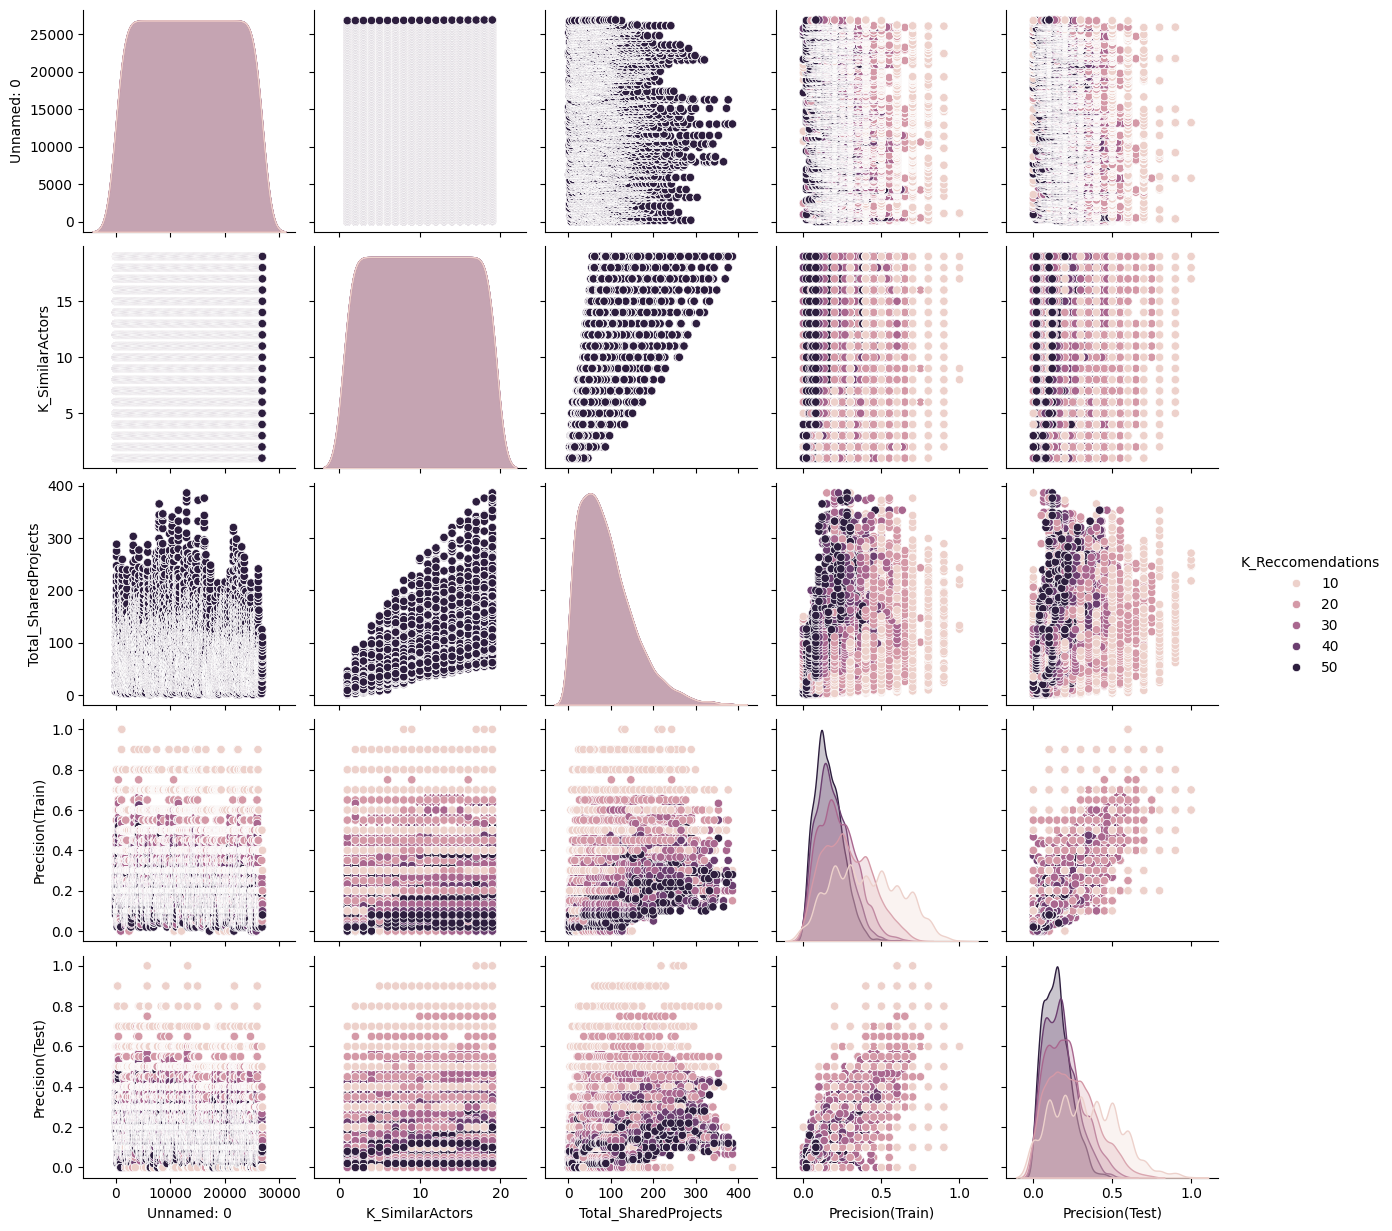

In [61]:
sns.pairplot(scores.drop(columns=['Personnel_ID', 'True_Positive(Train)', 'True_Positive(Test)']), hue='K_Reccomendations')
plt.show()

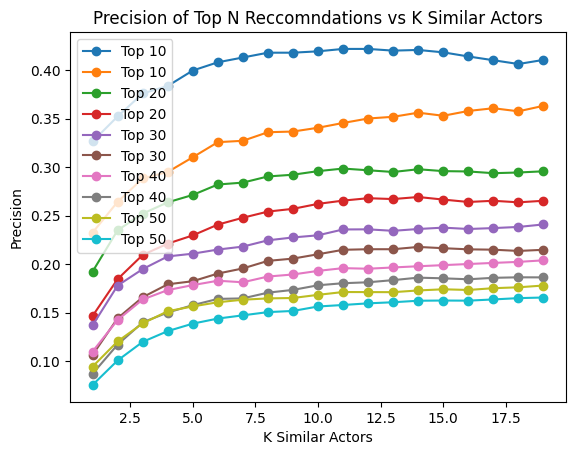

In [62]:
s = scores.groupby(['K_Reccomendations', 'K_SimilarActors'])[['Precision(Train)', 'Precision(Test)']].mean()

for i in np.arange(10,51,10):
    plt.plot(s.loc[i], label=f'Top {i}', marker='o')
plt.title('Precision of Top N Reccomndations vs K Similar Actors')
plt.xlabel('K Similar Actors')
plt.ylabel('Precision')

plt.legend()
plt.savefig(FILENAMES['UserPrecision']+'.png')

del s
plt.show()

The more reccomendations we make, the weaker precision becomes since there's more chances of it messing up.

The best performing was a Top 10 Reccomendation for Train and Test.

Thre's also a visibile `elbow` where improvements to Precision die off.

In most cases it's around K_Similar_Actors = 7.

Surprisingly adding more slightly less similar actors doesn't weaken reccomendations but stabilizes it.

### Improve
Still Poor Precision and Overfit from higher training score.

Let's see if a Model can perform better or help fit the sparse data.

# SVD

In [63]:
svd = TruncatedSVD(n_components=500)

U = svd.fit_transform(df_PerformanceScoring)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

Y = np.dot(U, np.dot(Sigma, Vt))

print(root_mean_squared_error(df_PerformanceScoring, Y))
del Y

1.370728100025667


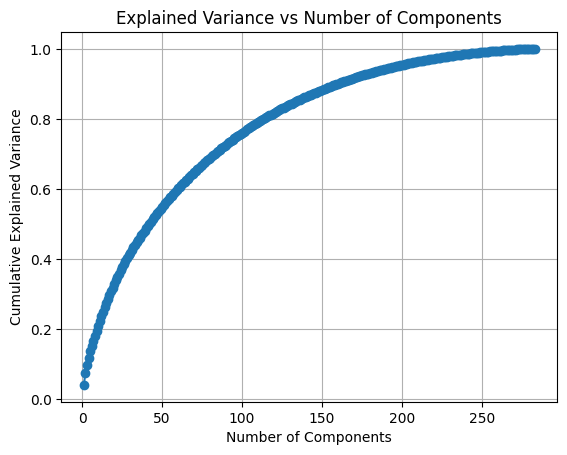

In [64]:
explained_variance = np.cumsum(svd.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()

### Try aiming for ~80%
150 Components

For comparisson, choosing an insufficient number of components, results in lower precision as seen below.

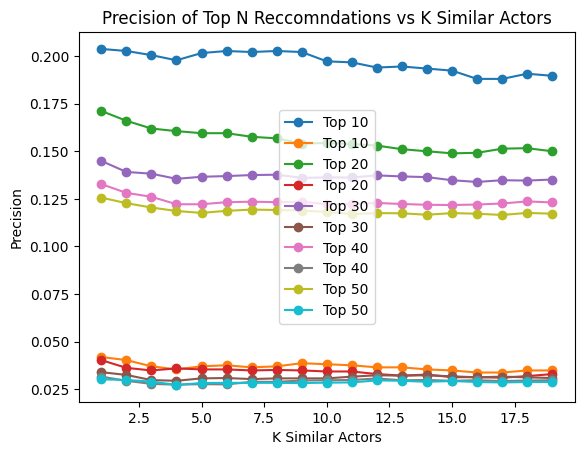

In [65]:
s = pd.read_csv(FILENAMES['UserSVDPrecision10'])
s = s.groupby(['K_Reccomendations', 'K_SimilarActors'])[['Precision(Train)', 'Precision(Test)']].mean()

for i in np.arange(10,51,10):
    plt.plot(s.loc[i], label=f'Top {i}', marker='o')
plt.title('Precision of Top N Reccomndations vs K Similar Actors')
plt.xlabel('K Similar Actors')
plt.ylabel('Precision')
plt.legend()

plt.savefig(FILENAMES['UserSVDPrecision10']+'.png')
plt.show()

del s

In [66]:
svd = TruncatedSVD(n_components=150)

U = svd.fit_transform(df_PerformanceScoring.T)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

SVD_UserItem = np.dot(U, np.dot(Sigma, Vt))

print('Train RMSE:\t', root_mean_squared_error(df_PerformanceScoring.T, SVD_UserItem))

X_test = pd.read_pickle(FILENAMES['X_test_100roles'])
X_test = pd.pivot_table(X_test, columns='Anime_ID', index='Personnel_ID', values='STD_Character_Favorites', aggfunc='mean').fillna(0)

U = svd.transform(X_test.T)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

SVD_UserItemTest = np.dot(U, np.dot(Sigma, Vt))

print('Test RMSE:\t', root_mean_squared_error(X_test.T, SVD_UserItemTest))

Train RMSE:	 2.673427231576554
Test RMSE:	 2.3350326252096605


Not exactly good.
Predictions for Train and Test are 2 standard deviations away from the truth.

In [67]:
df_PerformanceScoring = pd.DataFrame(SVD_UserItem.T, index=df_PerformanceScoring.index, columns=df_PerformanceScoring.columns)
df_Collabs = pd.DataFrame(cosine_similarity(df_PerformanceScoring), index=df_PerformanceScoring.index, columns=df_PerformanceScoring.index)
df_Collabs.head(10)

Personnel_ID,1,2,3,5,6,8,10,11,13,14,...,42840,44343,44721,45362,47003,47671,47713,51029,56579,56593
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.010324,0.048572,-0.003949,0.009454,-0.017093,-0.000090,-0.027137,0.483703,-0.021567,...,0.002548,0.035646,-0.010280,-0.013852,-0.029419,-0.006015,-0.000701,-0.008838,-0.026572,-0.011313
2,-0.010324,1.000000,-0.058660,0.445244,-0.056809,0.714521,-0.000917,-0.352064,-0.020685,0.012912,...,-0.006389,-0.047316,0.005552,0.002765,-0.054381,0.005064,-0.005734,-0.021815,-0.018362,0.034741
3,0.048572,-0.058660,1.000000,0.004484,-0.063697,-0.012352,0.295319,-0.233326,0.042502,0.001079,...,-0.219421,-0.004056,0.010628,-0.007192,-0.008872,-0.029326,0.008232,-0.006962,-0.163451,-0.008317
5,-0.003949,0.445244,0.004484,1.000000,0.114417,0.342133,0.004807,-0.257861,-0.087324,0.007112,...,0.133000,0.100143,0.084729,0.018393,-0.003710,0.009268,-0.026232,0.006755,-0.030594,0.026169
6,0.009454,-0.056809,-0.063697,0.114417,1.000000,-0.061764,-0.035674,0.056853,0.003885,-0.011797,...,0.082507,0.028348,-0.010608,-0.022131,-0.062423,-0.052828,-0.011580,-0.019612,0.235449,-0.110780
8,-0.017093,0.714521,-0.012352,0.342133,-0.061764,1.000000,0.013789,-0.464958,-0.028389,0.014578,...,-0.003743,0.038322,0.022156,0.010355,-0.002450,-0.017840,0.000130,-0.005530,0.112098,0.068780
10,-0.000090,-0.000917,0.295319,0.004807,-0.035674,0.013789,1.000000,-0.135927,0.006335,-0.001952,...,-0.107731,0.009972,0.017357,-0.005207,-0.004584,-0.038687,-0.001368,-0.001333,-0.096739,0.000846
11,-0.027137,-0.352064,-0.233326,-0.257861,0.056853,-0.464958,-0.135927,1.000000,-0.016190,-0.041153,...,0.126873,-0.046541,-0.362285,0.109029,-0.259969,-0.054170,-0.068688,-0.110238,-0.072229,-0.175220
13,0.483703,-0.020685,0.042502,-0.087324,0.003885,-0.028389,0.006335,-0.016190,1.000000,-0.000086,...,-0.034932,0.000006,-0.017886,-0.046903,-0.010353,-0.010697,-0.008533,-0.002295,-0.060264,-0.053291


In [68]:
# scores = []
# for ACTOR in df_Collabs.index:
#     for K_ACTORS in np.arange(1, 20):
#         for K_REC in np.arange(10,51,10):
#             scores.append(EvaluateScores(ACTOR,K_ACTORS,K_REC))
# scores = pd.DataFrame(scores)
# scores.to_csv(FILENAMES['UserSVDPrecision150'])


# ---------------------------------
# Skip loading since already saved.
# ---------------------------------

scores = pd.read_csv(FILENAMES['UserSVDPrecision150'])

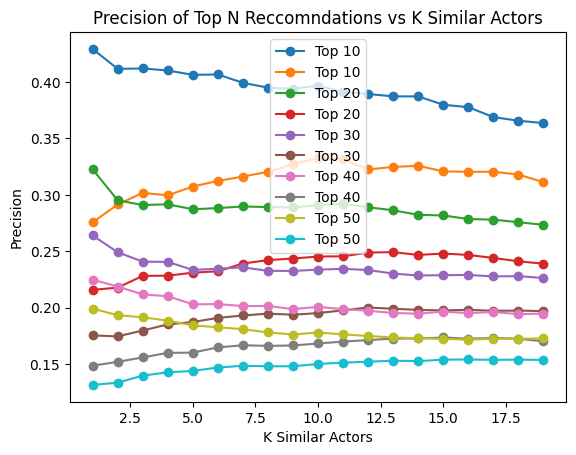

In [69]:
s = scores.groupby(['K_Reccomendations', 'K_SimilarActors'])[['Precision(Train)', 'Precision(Test)']].mean()

for i in np.arange(10,51,10):
    plt.plot(s.loc[i], label=f'Top {i}', marker='o')
plt.title('Precision of Top N Reccomndations vs K Similar Actors')
plt.xlabel('K Similar Actors')
plt.ylabel('Precision')
plt.legend()
plt.savefig(FILENAMES['UserSVDPrecision150']+'.png')
plt.show()
del s
del svd

### Discussion
A stark contrast to the non-SVD version, the trends are visibly different.

Train precision starts off strong and decreases as more K Similar Actors are used to generate reccomendations.

While the opposite is true for Test Case.

Still the recommendation size is Top 10 and more mistakes are introduced as the pool is increased.

Another similarity is still that the trends will eventually stabilize after reach K_SimilarActor elbow.

This indicates that the SVD was succesful in to some degree finding patterns when we decomposed and rebuilt the matrix.

The K amount of similar actors/users can provide the most likely recommendation at around K 10.

But if sparsity is the main challenge for SVDs, will it improve if we reduce sparsity?

#### Reload again except this time, reduce sparsity and compare once more.

In [70]:
X_train = pd.read_pickle(FILENAMES['X_train_100roles'])
df_PerformanceScoring = pd.pivot_table(X_train, index='Personnel_ID', columns='Anime_ID', values='STD_Character_Favorites', aggfunc='mean')
del X_train

Note what we've essentially done is removed Anime with less VAs than the threshold.

In [71]:
CalcSparsity(df_PerformanceScoring.dropna(thresh=20, axis=1))

df_PerformanceScoring = df_PerformanceScoring.dropna(thresh=10, axis=0).dropna(thresh=10, axis=1)
df_PerformanceScoring = df_PerformanceScoring.fillna(0)
df_PerformanceScoring

Sparsity:  11.07 %


Anime_ID,21,235,269,516,777,918,966,1565,1604,1735,...,57864,58510,58511,58516,58572,58592,59465,59493,59571,59989
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,-0.259482,0.000000,-0.325588,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.065837,0.000000,-0.310209,0.00000,0.0,1.793576,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.306317,-0.370660,4.365567,-0.37066,0.0,-0.199819,0.000000,-0.060324,0.000000,-0.369921,...,-0.193902,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.587307,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,-0.205488,-0.282679,-0.208696,0.00000,0.0,0.000000,-0.244249,0.000000,0.000000,1.670496,...,0.000000,0.0,-0.286762,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47671,-0.244485,0.000000,-0.176967,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,-0.247822,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47713,-0.243791,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,-0.238294,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51029,-0.197414,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
# scores = []
# for ACTOR in df_Collabs.index:
#     for K_ACTORS in np.arange(1, 20):
#         for K_REC in np.arange(10,51,10):
#             scores.append(EvaluateScores(ACTOR,K_ACTORS,K_REC))
# scores = pd.DataFrame(scores)
# scores.to_csv(FILENAMES['UserPrecisionLessSparse'])


# ---------------------------------
# Skip loading since already saved.
# ---------------------------------

scores = pd.read_csv(FILENAMES['UserPrecisionLessSparse'])
scores[['Precision(Train)', 'Precision(Test)']].mean()

Precision(Train)    0.229085
Precision(Test)     0.203887
dtype: float64

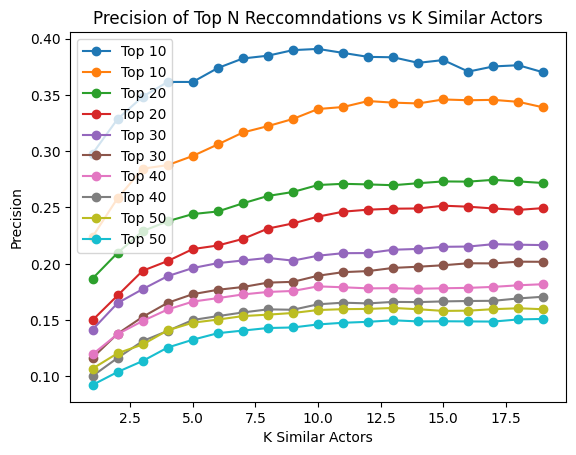

In [73]:
s = scores.groupby(['K_Reccomendations', 'K_SimilarActors'])[['Precision(Train)', 'Precision(Test)']].mean()

for i in np.arange(10,51,10):
    plt.plot(s.loc[i], label=f'Top {i}', marker='o')
plt.title('Precision of Top N Reccomndations vs K Similar Actors')
plt.xlabel('K Similar Actors')
plt.ylabel('Precision')

plt.legend()
plt.savefig(FILENAMES['UserPrecisionLessSparse']+'.png')

del s
plt.show()

It's the same trend and score but slightly bumpier/noisier than the regular more sparse ver.

### 100 Components
Check for 80%

3.0464762443388547


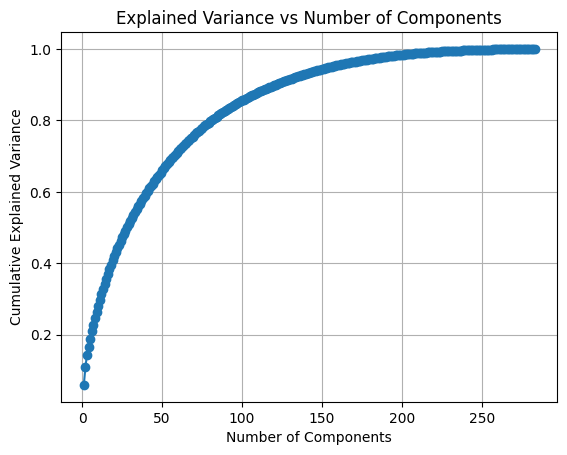

In [74]:
svd = TruncatedSVD(n_components=500)

U = svd.fit_transform(df_PerformanceScoring)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

Y = np.dot(U, np.dot(Sigma, Vt))

print(root_mean_squared_error(df_PerformanceScoring, Y))
del Y

explained_variance = np.cumsum(svd.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()

In [75]:
svd = TruncatedSVD(n_components=100)

U = svd.fit_transform(df_PerformanceScoring.T)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

SVD_UserItem = np.dot(U, np.dot(Sigma, Vt))

print('Train RMSE:\t', root_mean_squared_error(df_PerformanceScoring.T, SVD_UserItem))

X_test = pd.read_pickle(FILENAMES['X_test_100roles'])
X_test = pd.pivot_table(X_test, columns='Anime_ID', index='Personnel_ID', values='STD_Character_Favorites', aggfunc='mean').fillna(0)

U = svd.transform(X_test.T)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

SVD_UserItemTest = np.dot(U, np.dot(Sigma, Vt))

print('Test RMSE:\t', root_mean_squared_error(X_test.T, SVD_UserItemTest))

df_PerformanceScoring = pd.DataFrame(SVD_UserItem.T, index=df_PerformanceScoring.index, columns=df_PerformanceScoring.columns)
df_Collabs = pd.DataFrame(cosine_similarity(df_PerformanceScoring), index=df_PerformanceScoring.index, columns=df_PerformanceScoring.index)
df_Collabs.head(10)

Train RMSE:	 4.409396705142856
Test RMSE:	 1.981649256628639


Personnel_ID,1,2,3,5,6,8,10,11,13,14,...,42840,44343,44721,45362,47003,47671,47713,51029,56579,56593
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.011325,-0.011746,-0.009602,0.011837,-0.021243,-0.000105,-0.010319,0.784911,0.058711,...,0.022070,0.048650,-0.017159,-0.046572,-0.041759,-0.004821,0.011250,-0.016663,-0.042898,-0.017874
2,-0.011325,1.000000,-0.051896,0.418917,-0.067667,0.709315,-0.002323,-0.352011,-0.046117,0.075457,...,-0.084127,-0.062611,0.013994,-0.002843,-0.065150,0.020570,-0.007907,-0.035990,-0.033321,0.046155
3,-0.011746,-0.051896,1.000000,0.007064,-0.079996,-0.026537,0.328183,-0.267481,0.068025,-0.000221,...,-0.290317,-0.003465,-0.015039,-0.016941,-0.002820,-0.051228,0.008399,-0.009467,-0.202279,-0.009781
5,-0.009602,0.418917,0.007064,1.000000,0.111197,0.249717,0.011771,-0.251017,-0.010369,-0.170686,...,0.039681,0.089455,0.100258,-0.047376,-0.012661,0.003249,-0.018817,0.009539,-0.075625,0.023591
6,0.011837,-0.067667,-0.079996,0.111197,1.000000,-0.081610,-0.033270,0.078485,0.000301,0.038447,...,0.158898,0.030863,-0.019796,-0.039714,-0.074006,-0.103659,-0.023814,-0.027981,0.127331,-0.116016
8,-0.021243,0.709315,-0.026537,0.249717,-0.081610,1.000000,0.002488,-0.472395,-0.053034,0.142530,...,-0.146209,0.050283,0.028552,-0.003533,0.001359,-0.036958,0.007271,-0.009323,0.156937,0.114650
10,-0.000105,-0.002323,0.328183,0.011771,-0.033270,0.002488,1.000000,-0.142391,0.016503,0.040269,...,-0.125856,0.008870,0.006394,-0.004262,-0.002763,-0.060542,-0.000158,-0.000850,-0.106700,-0.001466
11,-0.010319,-0.352011,-0.267481,-0.251017,0.078485,-0.472395,-0.142391,1.000000,-0.011152,-0.168986,...,0.360196,-0.055600,-0.387845,0.182472,-0.264077,-0.023870,-0.047347,-0.115983,-0.015778,-0.181839
13,0.784911,-0.046117,0.068025,-0.010369,0.000301,-0.053034,0.016503,-0.011152,1.000000,0.045035,...,-0.031046,0.006153,-0.021855,-0.103606,-0.012203,-0.018356,-0.011451,-0.005458,-0.080696,-0.091645


The RMSEs are significantly different.

Previously both train and test were 2 standard devioations away from the truth.

In [76]:
# scores = []
# for ACTOR in df_Collabs.index:
#     for K_ACTORS in np.arange(1, 20):
#         for K_REC in np.arange(10,51,10):
#             scores.append(EvaluateScores(ACTOR,K_ACTORS,K_REC))
# scores = pd.DataFrame(scores)
# scores.to_csv(FILENAMES['UserSVDPrecisionLessSparse'])


# ---------------------------------
# Skip loading since already saved.
# ---------------------------------

scores = pd.read_csv(FILENAMES['UserSVDPrecisionLessSparse'])

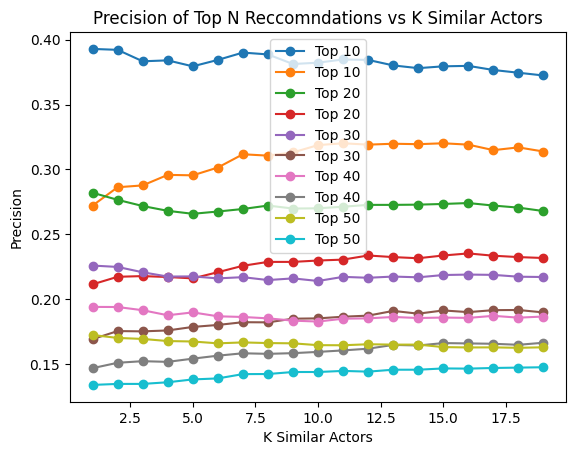

In [77]:
s = scores.groupby(['K_Reccomendations', 'K_SimilarActors'])[['Precision(Train)', 'Precision(Test)']].mean()

for i in np.arange(10,51,10):
    plt.plot(s.loc[i], label=f'Top {i}', marker='o')
plt.title('Precision of Top N Reccomndations vs K Similar Actors')
plt.xlabel('K Similar Actors')
plt.ylabel('Precision')
plt.legend()
plt.savefig(FILENAMES['UserSVDPrecisionLessSparse']+'.png')
plt.show()
del s
del svd

There's not much difference between SVD performed on a sparse vs less sparse dataset.

The same trends are still observed with just some slight stagnatios between phases.